In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
!ls -al /content/drive/MyDrive/binfo1-datapack1/

total 7162852
-r-------- 1 root root 1370036258 Apr 27  2023 CLIP-35L33G.bam
-r-------- 1 root root    3118336 Apr 27  2023 CLIP-35L33G.bam.bai
-r-------- 1 root root       7113 May 11  2023 CLIP-let7g.bam
-r-------- 1 root root      14561 May 11  2023 CLIP-let7g-gene.pileup
-r-------- 1 root root    2685065 May 11  2023 CLIP-let7g.pileup
-r-------- 1 root root  883334756 Apr 27  2023 gencode.gtf
-r-------- 1 root root   24065406 Apr 27  2023 read-counts.txt
-r-------- 1 root root        751 Apr 27  2023 read-counts.txt.summary
-r-------- 1 root root 1003658801 Apr 27  2023 RNA-control.bam
-r-------- 1 root root    2276104 Apr 27  2023 RNA-control.bam.bai
-r-------- 1 root root 1260991122 Apr 27  2023 RNA-siLin28a.bam
-r-------- 1 root root    2710744 Apr 27  2023 RNA-siLin28a.bam.bai
-r-------- 1 root root  981684502 Apr 27  2023 RNA-siLuc.bam
-r-------- 1 root root    2606104 Apr 27  2023 RNA-siLuc.bam.bai
-r-------- 1 root root  737352902 Apr 27  2023 RPF-siLin28a.bam
-r-------- 1 r

In [16]:
!cd /content/drive/MyDrive; mkdir cctest; touch cctest/.test; ls -al cctest/

total 0
-rw------- 1 root root 0 Apr 30 08:22 .test


In [26]:
!apt-get update
!apt-get install -y subread

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,990 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:1

In [28]:
!mkdir -p /content/drive/MyDrive/binfo1-work
%cd /content/drive/MyDrive/binfo1-work

/content/drive/MyDrive/binfo1-work


In [31]:
!featureCounts -a /content/drive/MyDrive/binfo1-datapack1/gencode.gtf -o read-counts.txt /content/drive/MyDrive/binfo1-datapack1/*.bam --tmpDir /tmp


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 7 BAM files                                      ||
||                                                                            ||
||                           CLIP-35L33G.bam                                  ||
||                           CLIP-let7g.bam                                   ||
||                           RNA-control.bam                     

In [34]:
import pandas as pd
cnts = pd.read_csv('read-counts.txt', sep='\t', comment='#', index_col=0)

# Extract only the basename of the column names that are file paths
# The first 5 columns ('Chr', 'Start', 'End', 'Strand', 'Length') should remain as is.
new_column_names = list(cnts.columns[:5])
for col in cnts.columns[5:]:
    new_column_names.append(col.split('/')[-1])
cnts.columns = new_column_names

cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
Geneid,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,0,1,1,1,0,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,0


In [35]:
import numpy as np

# Add a pseudocount of 1 to both numerator and denominator to avoid division by zero
# and ensure finite, positive values for log-transformation.
cnts['clip_enrichment'] = (cnts['CLIP-35L33G.bam'] + 1) / (cnts['RNA-control.bam'] + 1)
cnts['rden_change'] = ((cnts['RPF-siLin28a.bam'] + 1) / (cnts['RNA-siLin28a.bam'] + 1)) / ((cnts['RPF-siLuc.bam'] + 1) / (cnts['RNA-siLuc.bam'] + 1))

cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam,clip_enrichment,rden_change
Geneid,,,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,0,1,1,1,0,0,4.0,NaN
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,0,inf,NaN
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,0,NaN,NaN


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


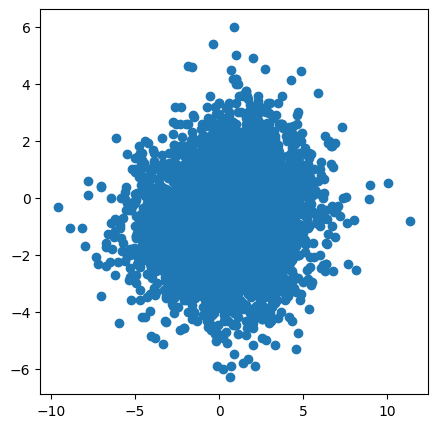

In [47]:
from matplotlib import pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log2(cnts['clip_enrichment']),
           np.log2(cnts['rden_change']))

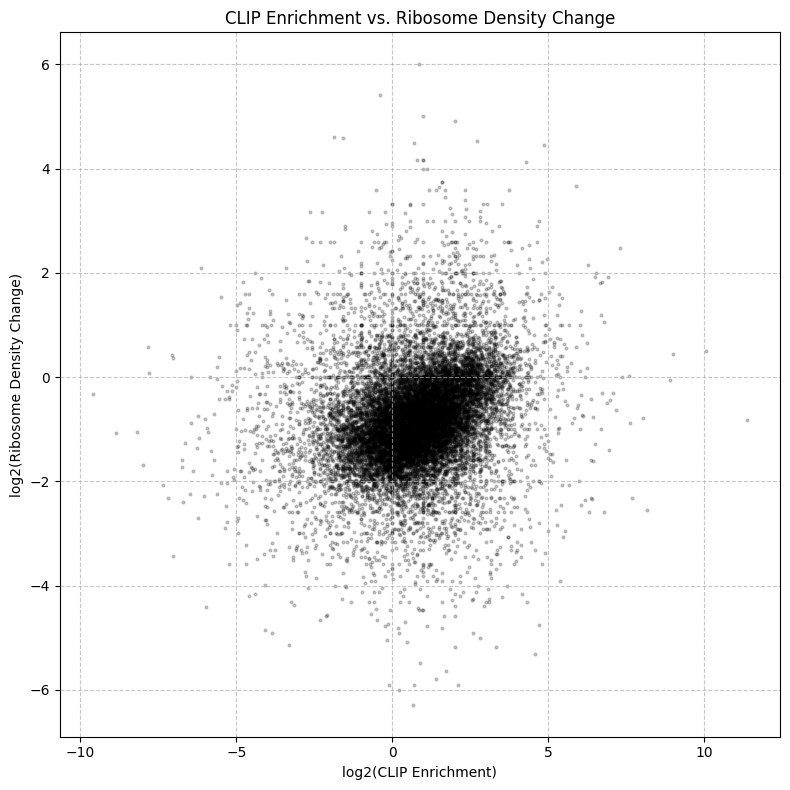

In [46]:
from matplotlib import pyplot as plt
import numpy as np

# Filter out rows where clip_enrichment or rden_change might be 0, NaN, or inf
# as log2 of these values would be problematic
plot_data = cnts.dropna(subset=['clip_enrichment', 'rden_change']).copy()
plot_data = plot_data[np.isfinite(plot_data['clip_enrichment']) & (plot_data['clip_enrichment'] > 0)]
plot_data = plot_data[np.isfinite(plot_data['rden_change']) & (plot_data['rden_change'] > 0)]

fig, ax = plt.subplots(1, 1, figsize=(8, 8)) # Increased figure size for better visibility

ax.scatter(np.log2(plot_data['clip_enrichment']),
           np.log2(plot_data['rden_change']),
           s=4, # Marker size
           alpha=0.2, # Transparency
           color='black') # Color of points changed to black for grayscale

ax.set_xlabel('log2(CLIP Enrichment)') # X-axis label
ax.set_ylabel('log2(Ribosome Density Change)') # Y-axis label
ax.set_title('CLIP Enrichment vs. Ribosome Density Change') # Plot title
ax.grid(True, linestyle='--', alpha=0.7) # Add a grid

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

In [52]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mouselocal = pd.read_csv('https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt', sep='\t')
mouselocal.head()

,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


Shape of merged_data before filtering: (55468, 16)
Number of common gene_ids between cleaned cnts and mouselocal: 9414
Shape after dropna on clip_enrichment and rden_change: (21326, 16)
Shape after ensuring positive values for log-transform: (17667, 16)
Shape of data with localization type for coloring: (7348, 16)


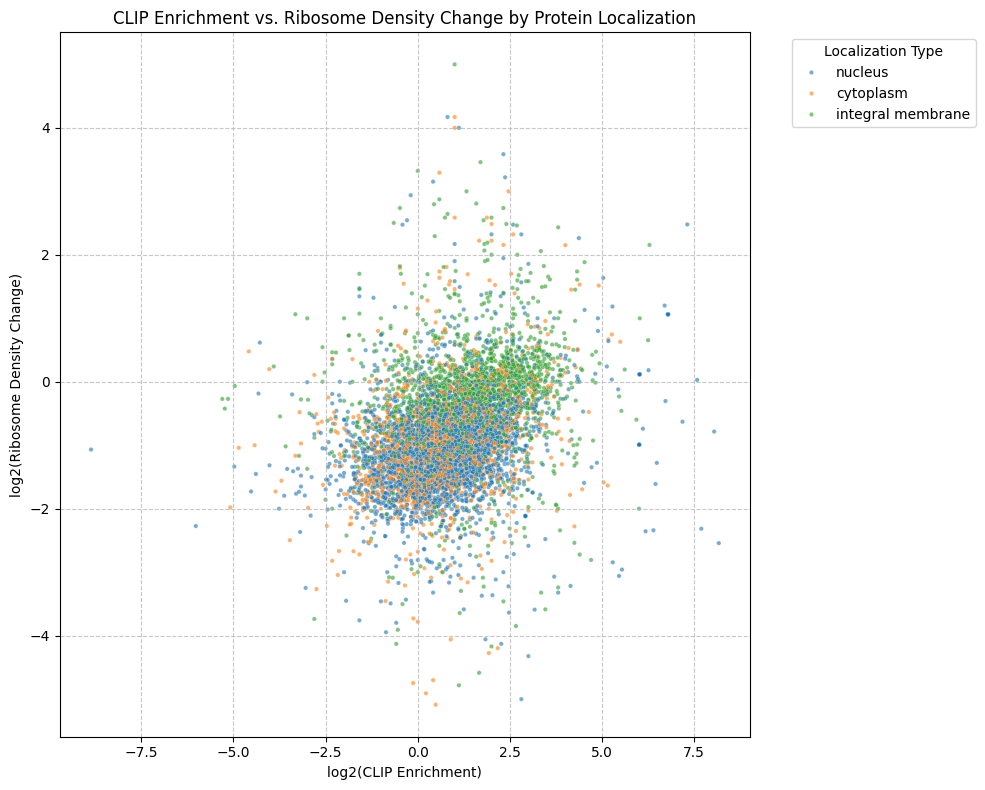

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Merge cnts with mouselocal data on gene_id
# The Geneid in cnts is the index, so we reset_index to join with mouselocal's gene_id
merged_data = cnts.reset_index().rename(columns={'Geneid': 'gene_id'})

# Clean gene_id by removing the version number (e.g., '.2') for merging
merged_data['gene_id'] = merged_data['gene_id'].apply(lambda x: x.split('.')[0])

merged_data = pd.merge(merged_data, mouselocal[['gene_id', 'type']], on='gene_id', how='left')

print(f"Shape of merged_data before filtering: {merged_data.shape}")

# Calculate the number of common gene_ids AFTER cleaning
# We'll re-calculate common_gene_ids using the cleaned gene_ids to see how many actually match
cleaned_cnts_gene_ids = set(cnts.reset_index()['Geneid'].apply(lambda x: x.split('.')[0]))
common_gene_ids_after_cleaning = len(cleaned_cnts_gene_ids.intersection(set(mouselocal['gene_id'])))
print(f"Number of common gene_ids between cleaned cnts and mouselocal: {common_gene_ids_after_cleaning}")

# Filter out rows where clip_enrichment or rden_change might be NaN or inf
# With pseudocounts, we expect these to be finite, but still filter for robustness
plot_data_final = merged_data.dropna(subset=['clip_enrichment', 'rden_change']).copy()
print(f"Shape after dropna on clip_enrichment and rden_change: {plot_data_final.shape}")

# Ensure values are strictly positive before log transformation
plot_data_final = plot_data_final[plot_data_final['clip_enrichment'] > 0]
plot_data_final = plot_data_final[plot_data_final['rden_change'] > 0]
print(f"Shape after ensuring positive values for log-transform: {plot_data_final.shape}")

# Now, filter out NaN 'type' for coloring, as requested by the user for points with location info only
plot_data_colored = plot_data_final.dropna(subset=['type']).copy()
print(f"Shape of data with localization type for coloring: {plot_data_colored.shape}")

if plot_data_colored.empty:
    print("plot_data_colored is empty after all filters. No points to plot with localization data.")
else:
    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        x=np.log2(plot_data_colored['clip_enrichment']),
        y=np.log2(plot_data_colored['rden_change']),
        hue='type', # Color points by protein localization type
        data=plot_data_colored,
        s=10, # Marker size
        alpha=0.6, # Transparency
        palette='tab10' # Use a color palette with distinct colors for categories
    )

    plt.xlabel('log2(CLIP Enrichment)') # X-axis label
    plt.ylabel('log2(Ribosome Density Change)') # Y-axis label
    plt.title('CLIP Enrichment vs. Ribosome Density Change by Protein Localization') # Plot title
    plt.grid(True, linestyle='--', alpha=0.7) # Add a grid
    plt.legend(title='Localization Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show() # Display the plot